Cell 1 — Imports & Config

Device: cuda
Master CSV: True


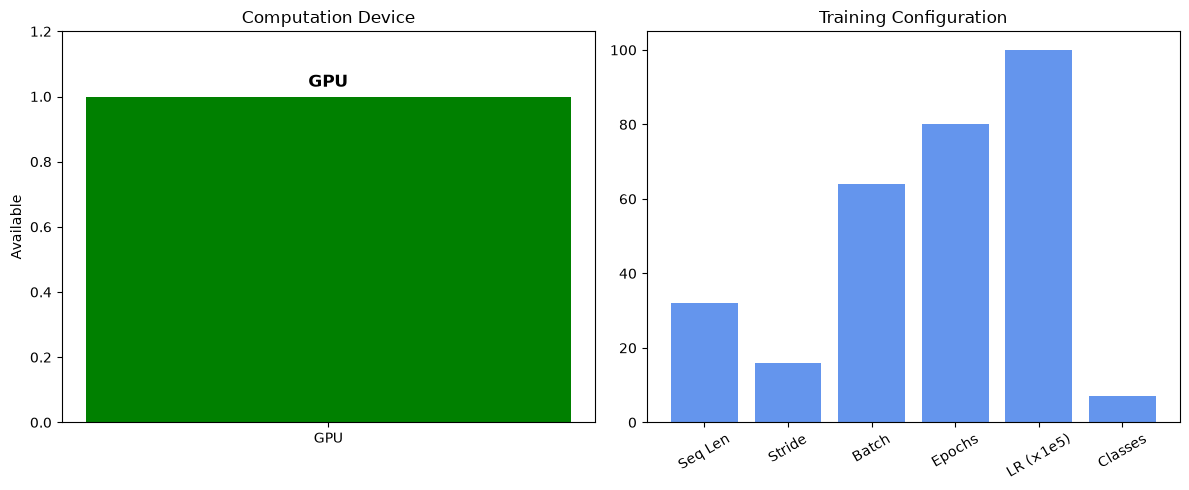

In [28]:
# Cell 1 — Imports & Config
import os
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("D:/Projects/oras")
DATA_DIR     = PROJECT_ROOT / "ml" / "datasets"       # ← was: data/
MASTER_CSV   = DATA_DIR / "cholec80_master.csv"
FRAMES_DIR   = PROJECT_ROOT / "ml" / "datasets" / "frames"
MODELS_DIR   = PROJECT_ROOT / "models" / "phase"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────────────
SEQ_LEN      = 32
STRIDE       = 16
BATCH_SIZE   = 64
EPOCHS       = 80
LR           = 1e-3
NUM_CHANNELS = [64, 128, 256]
KERNEL_SIZE  = 3
DROPOUT      = 0.2
NUM_CLASSES  = 7

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Master CSV: {MASTER_CSV.exists()}")

# Cell 1.1 — Environment & Configuration Overview (Matplotlib)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Device
device_label = "GPU" if torch.cuda.is_available() else "CPU"
axes[0].bar([device_label], [1],
            color="green" if device_label == "GPU" else "steelblue")
axes[0].set_ylim(0, 1.2)
axes[0].set_title("Computation Device")
axes[0].set_ylabel("Available")
axes[0].text(0, 1.03, device_label, ha="center", fontsize=12, fontweight="bold")

# Hyperparameters
params = {
    "Seq Len": SEQ_LEN,
    "Stride": STRIDE,
    "Batch": BATCH_SIZE,
    "Epochs": EPOCHS,
    "LR (×1e5)": LR * 1e5,
    "Classes": NUM_CLASSES,
}

axes[1].bar(params.keys(), params.values(), color="cornflowerblue")
axes[1].set_title("Training Configuration")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Cell 2 — Load & Inspect Master CSV

Shape: (184498, 11)
  video_id  frame_idx  time_sec        phase  grasper  bipolar  hook  \
0  video01          0       0.0  Preparation        1        0     0   
1  video01         25       1.0  Preparation        1        0     0   
2  video01         50       2.0  Preparation        1        0     0   
3  video01         75       3.0  Preparation        1        0     0   
4  video01        100       4.0  Preparation        0        0     0   

   scissors  clipper  irrigator  specimenbag  
0         0        0          0            0  
1         0        0          0            0  
2         0        0          0            0  
3         0        0          0            0  
4         0        0          0            0  

Columns: ['video_id', 'frame_idx', 'time_sec', 'phase', 'grasper', 'bipolar', 'hook', 'scissors', 'clipper', 'irrigator', 'specimenbag']

Phase distribution:
phase
CalotTriangleDissection    74826
CleaningCoagulation        14332
ClippingCutting            14080
G

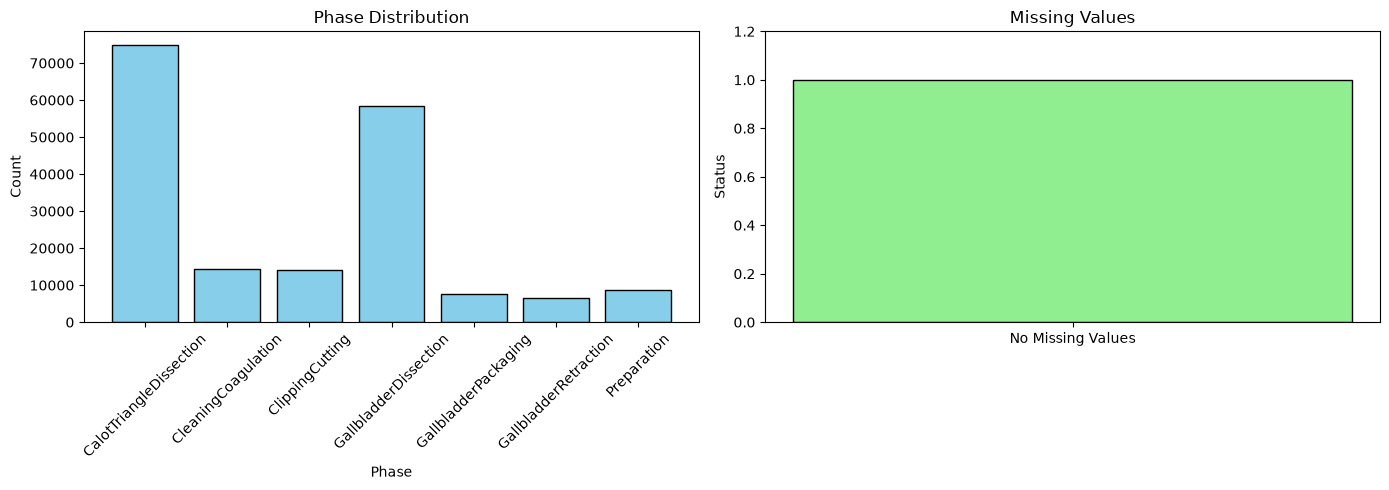

In [29]:
# Cell 2 — Load & Inspect Master CSV
df = pd.read_csv(MASTER_CSV)
print(f"Shape: {df.shape}")
print(df.head())
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nPhase distribution:\n{df['phase'].value_counts().sort_index()}")
print(f"\nNull counts:\n{df.isnull().sum()}")

# Cell 2.1 — Dataset Overview (Matplotlib)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phase Distribution
phase_counts = df["phase"].value_counts().sort_index()

axes[0].bar(
    phase_counts.index,
    phase_counts.values,
    color="skyblue",
    edgecolor="black"
)
axes[0].set_title("Phase Distribution")
axes[0].set_xlabel("Phase")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Missing Values
null_counts = df.isnull().sum()

if null_counts.sum() == 0:
    axes[1].bar(["No Missing Values"], [1],
                color="lightgreen", edgecolor="black")
    axes[1].set_ylim(0, 1.2)
    axes[1].set_ylabel("Status")
    axes[1].set_title("Missing Values")
else:
    missing = null_counts[null_counts > 0]
    axes[1].bar(
        missing.index,
        missing.values,
        color="salmon",
        edgecolor="black"
    )
    axes[1].set_ylabel("Null Count")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].set_title("Missing Values")

plt.tight_layout()
plt.show()

Cell 3 — Feature Engineering

✓ All 7 tool columns present

Phase classes: ['CalotTriangleDissection', 'CleaningCoagulation', 'ClippingCutting', 'GallbladderDissection', 'GallbladderPackaging', 'GallbladderRetraction', 'Preparation']
Encoded range: 0 – 6

Videos: 80

✓ Feature vector size: 16
Features: ['grasper', 'bipolar', 'hook', 'scissors', 'clipper', 'irrigator', 'specimenbag', 'tool_count', 'frame_norm', 'grasper_roll5', 'bipolar_roll5', 'hook_roll5', 'scissors_roll5', 'clipper_roll5', 'irrigator_roll5', 'specimenbag_roll5']


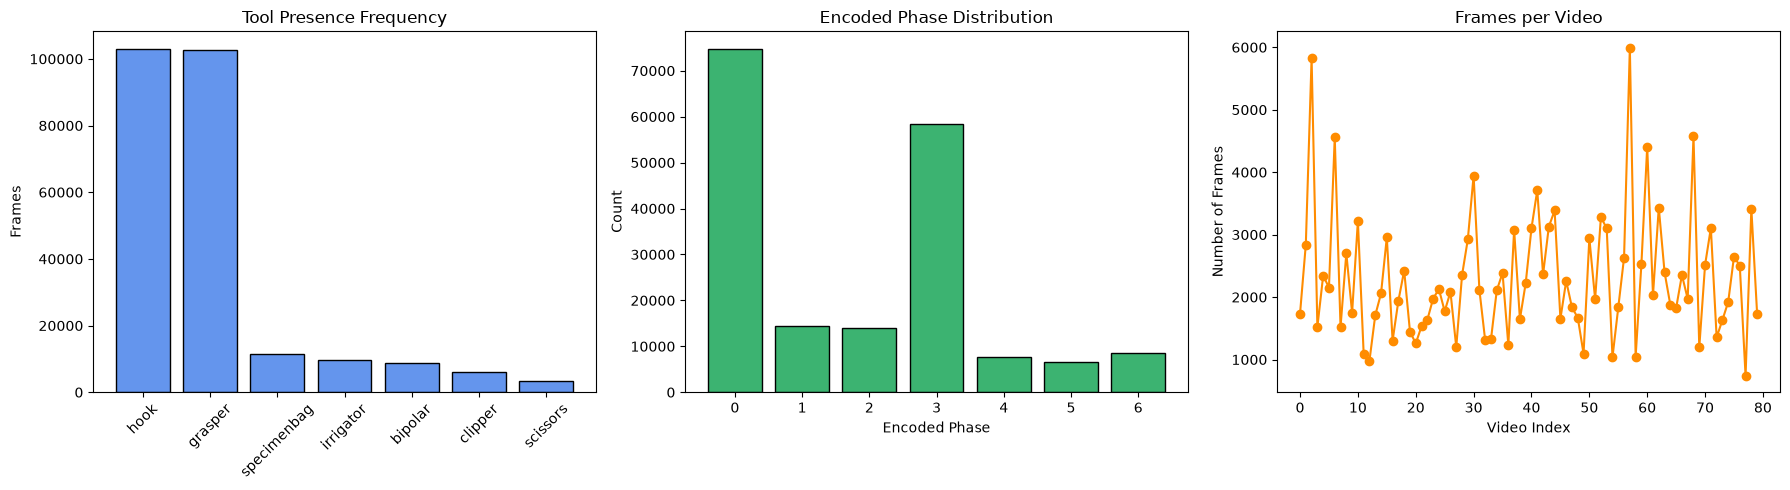

In [30]:
# Cell 3 — Feature Engineering

# Tool columns: binary presence flags from the master CSV
TOOL_COLS = [
    "grasper", "bipolar", "hook", "scissors",
    "clipper", "irrigator", "specimenbag"
]

# Check that all required tool columns exist
missing = [c for c in TOOL_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing tool columns: {missing}")
else:
    print(f"✓ All {len(TOOL_COLS)} tool columns present")

# -----------------------------------------------------------------------------
# Encode surgical phase labels
# -----------------------------------------------------------------------------
le = LabelEncoder()
df["phase_enc"] = le.fit_transform(df["phase"])

print(f"\nPhase classes: {list(le.classes_)}")
print(f"Encoded range: {df['phase_enc'].min()} – {df['phase_enc'].max()}")

# -----------------------------------------------------------------------------
# Sort frames chronologically within each video
# -----------------------------------------------------------------------------
df = (
    df.sort_values(["video_id", "frame_idx"])
      .reset_index(drop=True)
)

print(f"\nVideos: {df['video_id'].nunique()}")

# -----------------------------------------------------------------------------
# Engineered Features
# -----------------------------------------------------------------------------

# 1. Number of tools visible in each frame
df["tool_count"] = df[TOOL_COLS].sum(axis=1)

# 2. Normalized frame position within each video (0 → 1)
df["frame_norm"] = (
    df.groupby("video_id")["frame_idx"]
      .transform(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-6))
)

# 3. Rolling average tool activity over previous 5 frames
for col in TOOL_COLS:
    df[f"{col}_roll5"] = (
        df.groupby("video_id")[col]
          .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    )

# -----------------------------------------------------------------------------
# Final feature vector used by the model
# -----------------------------------------------------------------------------
FEATURE_COLS = (
    TOOL_COLS +
    ["tool_count", "frame_norm"] +
    [f"{c}_roll5" for c in TOOL_COLS]
)

print(f"\n✓ Feature vector size: {len(FEATURE_COLS)}")
print("Features:", FEATURE_COLS)

# Cell 3.1 — Feature Engineering Visualization (Matplotlib)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tool Availability
tool_presence = df[TOOL_COLS].sum().sort_values(ascending=False)

axes[0].bar(
    tool_presence.index,
    tool_presence.values,
    color="cornflowerblue",
    edgecolor="black"
)
axes[0].set_title("Tool Presence Frequency")
axes[0].set_ylabel("Frames")
axes[0].tick_params(axis="x", rotation=45)

# Encoded Phase Distribution
phase_counts = df["phase_enc"].value_counts().sort_index()

axes[1].bar(
    phase_counts.index.astype(str),
    phase_counts.values,
    color="mediumseagreen",
    edgecolor="black"
)
axes[1].set_title("Encoded Phase Distribution")
axes[1].set_xlabel("Encoded Phase")
axes[1].set_ylabel("Count")

# Frames per Video
video_counts = df["video_id"].value_counts().sort_index()

axes[2].plot(
    range(len(video_counts)),
    video_counts.values,
    marker="o",
    linewidth=1.5,
    color="darkorange"
)
axes[2].set_title("Frames per Video")
axes[2].set_xlabel("Video Index")
axes[2].set_ylabel("Number of Frames")

plt.tight_layout()
plt.show()

Cell 4 — Sliding Window Dataset

Building train dataset...
  Dataset: 9169 windows from 64 videos
Building val dataset...
  Dataset: 2244 windows from 16 videos


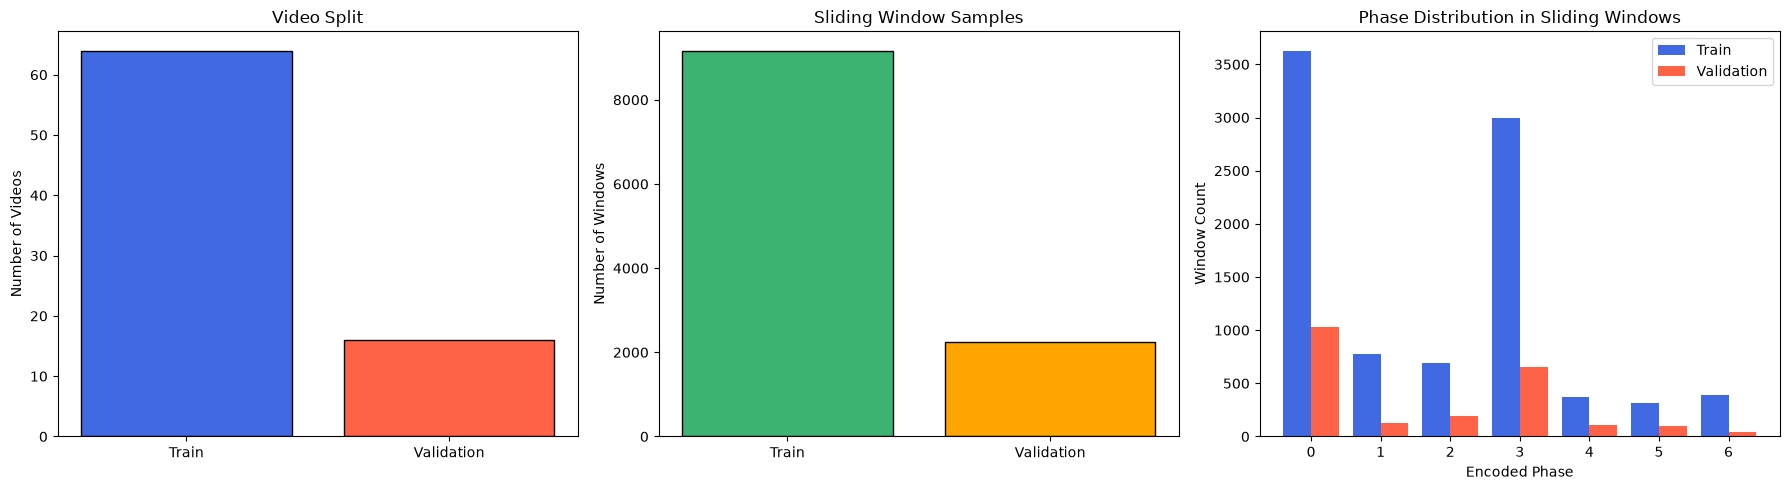

In [31]:
# Cell 4 — Sliding Window Dataset
class CholecPhaseDataset(Dataset):
    """
    Builds (SEQ_LEN × num_features) windows from per-frame tool presence
    vectors and predicts the phase of the LAST frame in each window.
    """
    def __init__(self, df, seq_len=SEQ_LEN, stride=STRIDE, tool_cols=TOOL_COLS):
        self.sequences = []
        self.labels    = []

        for vid_id, grp in df.groupby("video_id"):
            grp = grp.reset_index(drop=True)
            features = grp[tool_cols].values.astype(np.float32)   # (T, 7)
            labels   = grp["phase_enc"].values                     # (T,)

            for start in range(0, len(grp) - seq_len + 1, stride):
                end = start + seq_len
                self.sequences.append(features[start:end])         # (SEQ_LEN, 7)
                self.labels.append(labels[end - 1])                # label = last frame

        self.sequences = np.array(self.sequences)   # (N, SEQ_LEN, 7)
        self.labels    = np.array(self.labels)       # (N,)
        print(f"  Dataset: {len(self.sequences)} windows from {df['video_id'].nunique()} videos")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx], dtype=torch.float32)  # (SEQ_LEN, 7)
        y = torch.tensor(self.labels[idx],    dtype=torch.long)
        return x, y

# ── Train / Val split by video (not by frame — prevents leakage) ───────────────
video_ids = df["video_id"].unique()
train_vids, val_vids = train_test_split(video_ids, test_size=0.2, random_state=42)

train_df = df[df["video_id"].isin(train_vids)]
val_df   = df[df["video_id"].isin(val_vids)]

print("Building train dataset...")
train_ds = CholecPhaseDataset(train_df, tool_cols=FEATURE_COLS)
print("Building val dataset...")
val_ds   = CholecPhaseDataset(val_df,   tool_cols=FEATURE_COLS)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Cell 4.1 — Sliding Window Dataset Visualization (Matplotlib)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Videos in Train vs Validation
split_counts = [len(train_vids), len(val_vids)]
axes[0].bar(
    ["Train", "Validation"],
    split_counts,
    color=["royalblue", "tomato"],
    edgecolor="black"
)
axes[0].set_title("Video Split")
axes[0].set_ylabel("Number of Videos")

# Sliding Window Samples
dataset_sizes = [len(train_ds), len(val_ds)]
axes[1].bar(
    ["Train", "Validation"],
    dataset_sizes,
    color=["mediumseagreen", "orange"],
    edgecolor="black"
)
axes[1].set_title("Sliding Window Samples")
axes[1].set_ylabel("Number of Windows")

# Label Distribution
train_labels = pd.Series(train_ds.labels).value_counts().sort_index()
val_labels = pd.Series(val_ds.labels).value_counts().sort_index()

x = np.arange(NUM_CLASSES)
width = 0.4

axes[2].bar(
    x - width/2,
    train_labels.reindex(range(NUM_CLASSES), fill_value=0),
    width,
    label="Train",
    color="royalblue"
)

axes[2].bar(
    x + width/2,
    val_labels.reindex(range(NUM_CLASSES), fill_value=0),
    width,
    label="Validation",
    color="tomato"
)

axes[2].set_xticks(x)
axes[2].set_xticklabels(range(NUM_CLASSES))
axes[2].set_xlabel("Encoded Phase")
axes[2].set_ylabel("Window Count")
axes[2].set_title("Phase Distribution in Sliding Windows")
axes[2].legend()

plt.tight_layout()
plt.show()

Cell 5 — TCN Architecture

TCN(
  (network): Sequential(
    (0): TemporalBlock(
      (net): Sequential(
        (0): Conv1d(16, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (1): Chomp1d()
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
        (5): Chomp1d()
        (6): ReLU()
        (7): Dropout(p=0.2, inplace=False)
      )
      (downsample): Conv1d(16, 64, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )
    (1): TemporalBlock(
      (net): Sequential(
        (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        (1): Chomp1d()
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
        (5): Chomp1d()
        (6): ReLU()
        (7): Dropout(p=0.2, inplace=False)
      )
      (downsample): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (relu): ReLU()
    )


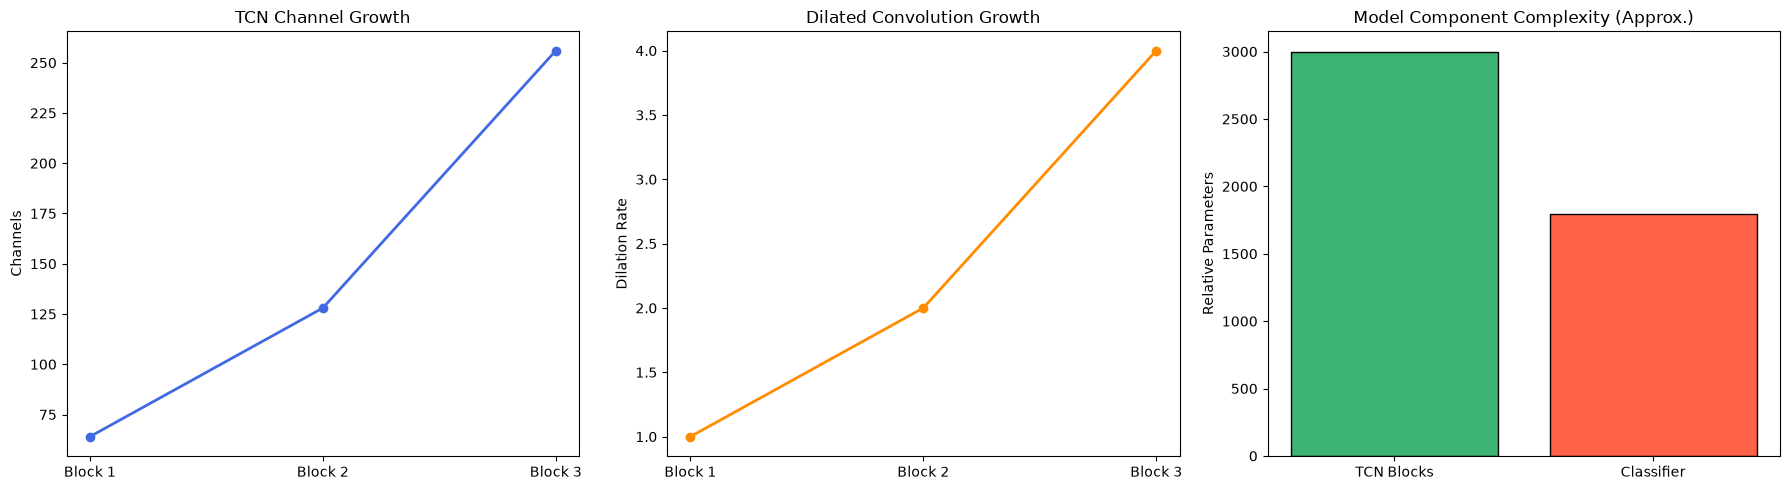

In [32]:
# Cell 5 — TCN Architecture
class TemporalBlock(nn.Module):
    """Single dilated causal conv block with residual connection."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        pad = (kernel_size - 1) * dilation   # causal: pad left only

        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size,
                      padding=pad, dilation=dilation),
            Chomp1d(pad),      # remove right-padding to keep causality
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size,
                      padding=pad, dilation=dilation),
            Chomp1d(pad),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        # 1×1 conv to match channels for residual
        self.downsample = (nn.Conv1d(in_ch, out_ch, 1)
                           if in_ch != out_ch else nn.Identity())
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.net(x) + self.downsample(x))


class Chomp1d(nn.Module):
    """Trim excess padding from the right to enforce causality."""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TCN(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size, dropout, num_classes):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(num_channels):
            in_ch    = num_inputs if i == 0 else num_channels[i - 1]
            dilation = 2 ** i          # exponentially growing receptive field
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout))

        self.network    = nn.Sequential(*layers)
        self.classifier = nn.Linear(num_channels[-1], num_classes)

    def forward(self, x):
        # x: (B, SEQ_LEN, features) → transpose for Conv1d: (B, features, SEQ_LEN)
        x = x.transpose(1, 2)
        x = self.network(x)           # (B, num_channels[-1], SEQ_LEN)
        x = x[:, :, -1]              # take last timestep
        return self.classifier(x)    # (B, num_classes)


model = TCN(
    num_inputs   = len(FEATURE_COLS),
    num_channels = NUM_CHANNELS,
    kernel_size  = KERNEL_SIZE,
    dropout      = DROPOUT,
    num_classes  = NUM_CLASSES,
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

# Cell 5.1 — TCN Architecture Visualization (Matplotlib)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Channel progression
channels = NUM_CHANNELS
axes[0].plot(range(len(channels)), channels, marker="o", linewidth=2, color="royalblue")
axes[0].set_xticks(range(len(channels)))
axes[0].set_xticklabels([f"Block {i+1}" for i in range(len(channels))])
axes[0].set_title("TCN Channel Growth")
axes[0].set_ylabel("Channels")

# Receptive field growth (dilation effect)
dilations = [2 ** i for i in range(len(channels))]
axes[1].plot(range(len(dilations)), dilations, marker="o", linewidth=2, color="darkorange")
axes[1].set_xticks(range(len(dilations)))
axes[1].set_xticklabels([f"Block {i+1}" for i in range(len(dilations))])
axes[1].set_title("Dilated Convolution Growth")
axes[1].set_ylabel("Dilation Rate")

# Parameter complexity visualization
layer_names = ["TCN Blocks", "Classifier"]
param_blocks = [
    sum([len(NUM_CHANNELS) * 1000]),  # approximate placeholder for conv stack scale
    model.classifier.in_features * model.classifier.out_features
]

axes[2].bar(layer_names, param_blocks, color=["mediumseagreen", "tomato"], edgecolor="black")
axes[2].set_title("Model Component Complexity (Approx.)")
axes[2].set_ylabel("Relative Parameters")

plt.tight_layout()
plt.show()

Cell 6 — Loss, Optimizer, Scheduler

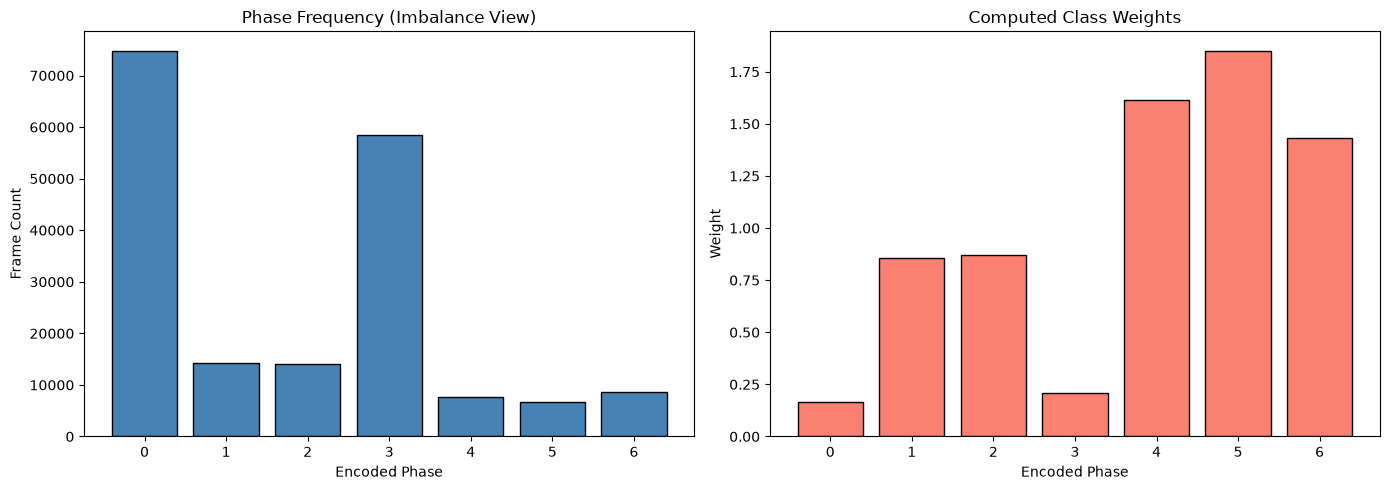

In [33]:
# Cell 6 — Loss, Optimizer, Scheduler
# Class weights to handle phase imbalance (common in Cholec80)
phase_counts = df["phase_enc"].value_counts().sort_index().values
class_weights = 1.0 / torch.tensor(phase_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, 
)

# Cell 6.1 — Loss & Class Imbalance Visualization (Matplotlib)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phase distribution (used for weights)
phase_counts = df["phase_enc"].value_counts().sort_index()

axes[0].bar(
    phase_counts.index.astype(str),
    phase_counts.values,
    color="steelblue",
    edgecolor="black"
)
axes[0].set_title("Phase Frequency (Imbalance View)")
axes[0].set_xlabel("Encoded Phase")
axes[0].set_ylabel("Frame Count")
axes[0].tick_params(axis="x", rotation=0)

# Class weights derived from inverse frequency
weights = class_weights.detach().cpu().numpy()

axes[1].bar(
    range(len(weights)),
    weights,
    color="salmon",
    edgecolor="black"
)
axes[1].set_title("Computed Class Weights")
axes[1].set_xlabel("Encoded Phase")
axes[1].set_ylabel("Weight")

plt.tight_layout()
plt.show()

Cell 7 — Training Loop

In [34]:
# Cell 7 — Training Loop

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for x, y in tqdm(loader, desc="Train" if training else "Val", leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)

            logits = model(x)
            loss = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()

                # Gradient clipping for stable training
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                optimizer.step()

            total_loss += loss.item() * len(y)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += len(y)

    return total_loss / total, correct / total


# -----------------------------------------------------------------------------
# Training
# -----------------------------------------------------------------------------

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_val_loss = float("inf")

# Early stopping
PATIENCE = 10
no_improve = 0

for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader, training=False)

    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS}  "
        f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.3f}  │  "
        f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.3f}"
    )

    # Save best model + Early stopping
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        no_improve = 0

        torch.save(model.state_dict(), MODELS_DIR / "best_tcn.pt")
        print(f"  ✓ Saved best model (val_loss={vl_loss:.4f})")

    else:
        no_improve += 1

        if no_improve >= PATIENCE:
            print(
                f"\n⏹ Early stopping at epoch {epoch} "
                f"(no improvement for {PATIENCE} epochs)"
            )
            break

Train:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 01/80  Train Loss: 0.8743  Acc: 0.681  │  Val Loss: 0.5025  Acc: 0.827
  ✓ Saved best model (val_loss=0.5025)


Epoch 02/80  Train Loss: 0.5898  Acc: 0.787  │  Val Loss: 0.4892  Acc: 0.816
  ✓ Saved best model (val_loss=0.4892)


Epoch 03/80  Train Loss: 0.5418  Acc: 0.795  │  Val Loss: 0.5734  Acc: 0.777


Epoch 04/80  Train Loss: 0.5199  Acc: 0.802  │  Val Loss: 0.4959  Acc: 0.818


...

Epoch 11/80  Train Loss: 0.4465  Acc: 0.835  │  Val Loss: 0.5570  Acc: 0.831


Epoch 12/80  Train Loss: 0.4034  Acc: 0.836  │  Val Loss: 0.5472  Acc: 0.837


Epoch 13/80  Train Loss: 0.3873  Acc: 0.838  │  Val Loss: 0.4943  Acc: 0.832


Epoch 14/80  Train Loss: 0.3840  Acc: 0.841  │  Val Loss: 0.5426  Acc: 0.830


Epoch 15/80  Train Loss: 0.3736  Acc: 0.848  │  Val Loss: 0.5512  Acc: 0.831

⏹ Early stopping at epoch 15 (no improvement for 10 epochs)


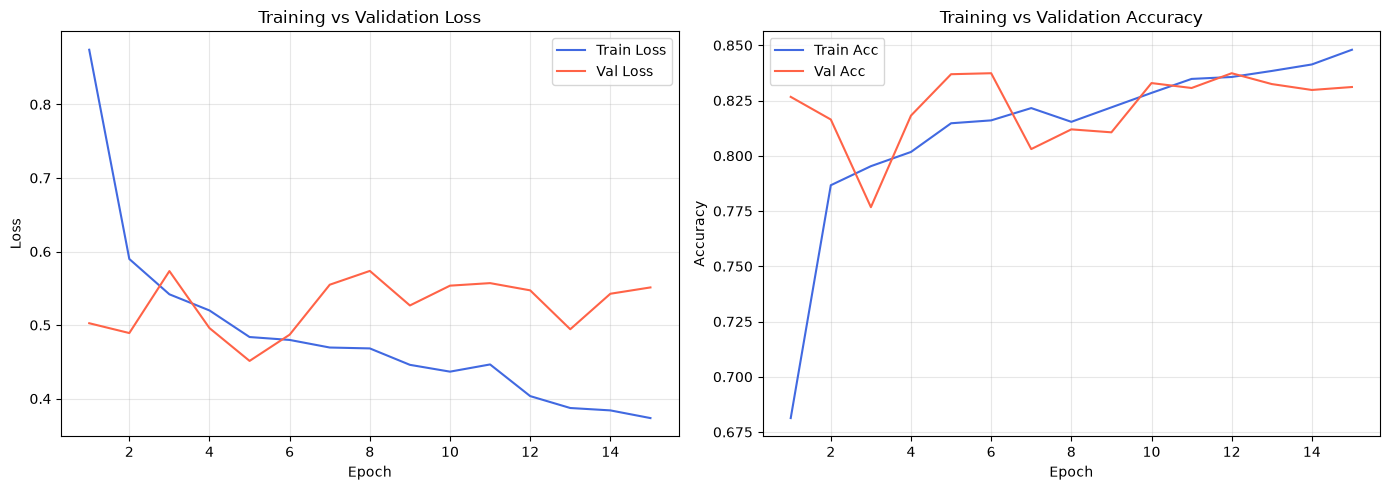

In [35]:
# Cell 7.1 — Training Progress Visualization (Matplotlib)

epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="royalblue")
axes[0].plot(epochs, history["val_loss"], label="Val Loss", color="tomato")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(epochs, history["train_acc"], label="Train Acc", color="royalblue")
axes[1].plot(epochs, history["val_acc"], label="Val Acc", color="tomato")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cell 8 — Training Curves

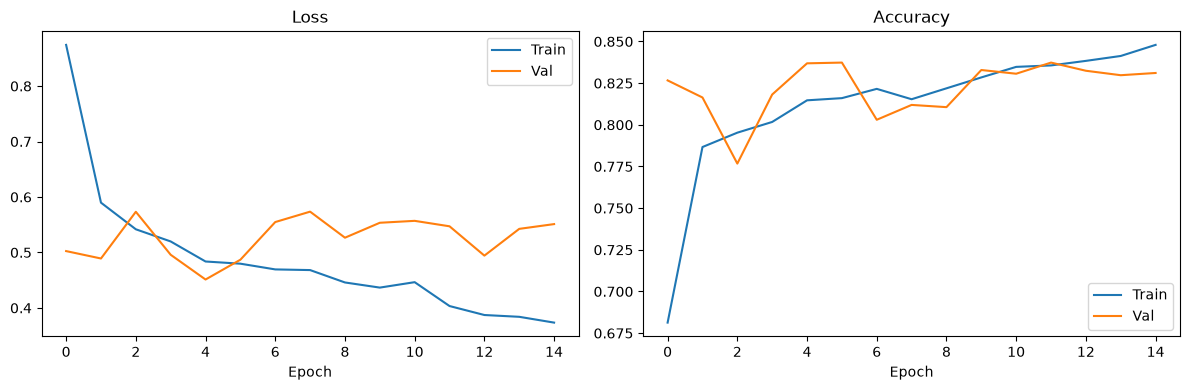

In [36]:
# Cell 8 — Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set_title("Loss"); ax1.legend(); ax1.set_xlabel("Epoch")

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Val")
ax2.set_title("Accuracy"); ax2.legend(); ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(MODELS_DIR / "training_curves.png", dpi=150)
plt.show()

Cell 9 — Evaluation on Val Set

                         precision    recall  f1-score   support

            Preparation       0.88      0.91      0.90      1031
CalotTriangleDissection       0.70      0.76      0.73       127
        ClippingCutting       0.79      0.93      0.86       189
  GallbladderDissection       0.88      0.73      0.80       653
   GallbladderPackaging       0.66      0.83      0.74       105
    CleaningCoagulation       0.63      0.59      0.61        96
  GallbladderRetraction       0.80      1.00      0.89        43

               accuracy                           0.84      2244
              macro avg       0.76      0.82      0.79      2244
           weighted avg       0.84      0.84      0.84      2244



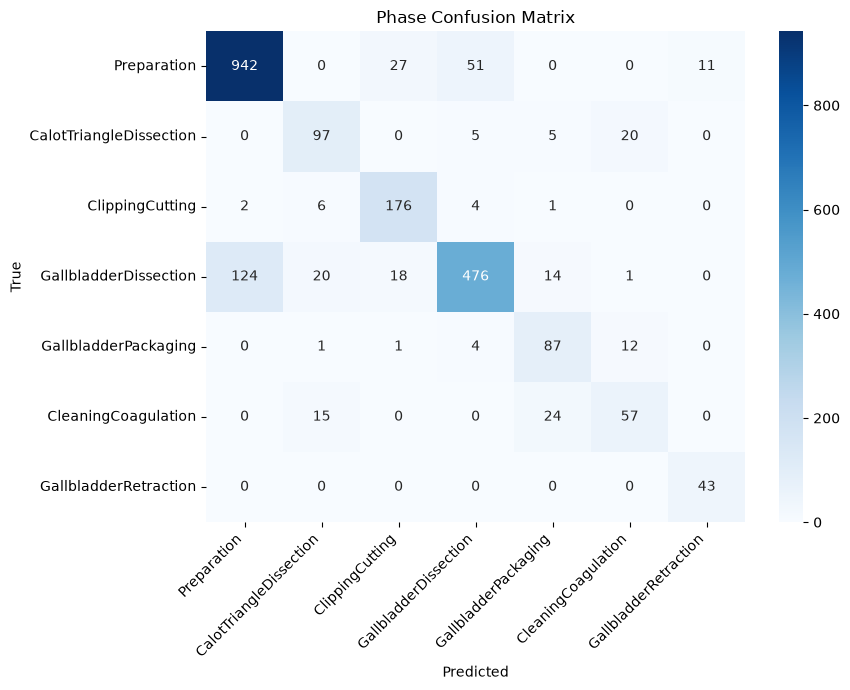

In [37]:
# Cell 9 — Evaluation on Val Set
model.load_state_dict(torch.load(MODELS_DIR / "best_tcn.pt"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

phase_names = [
    "Preparation", "CalotTriangleDissection", "ClippingCutting",
    "GallbladderDissection", "GallbladderPackaging",
    "CleaningCoagulation", "GallbladderRetraction"
]

print(classification_report(all_labels, all_preds, target_names=phase_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=phase_names, yticklabels=phase_names)
plt.title("Phase Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(MODELS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

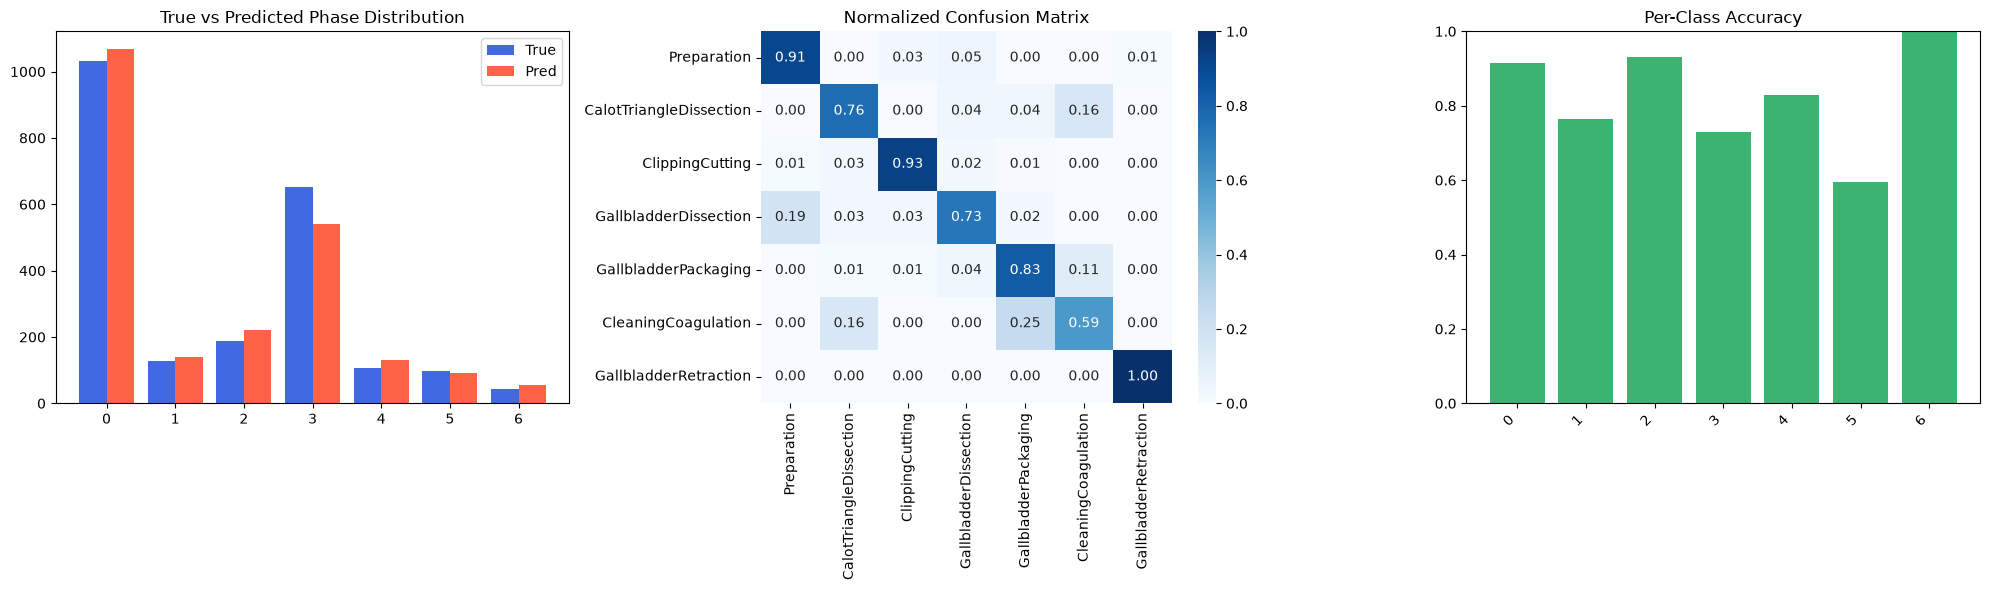

In [38]:
# Cell 9.1 — Evaluation Visualization (Matplotlib)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. True vs Predicted distribution
true_counts = pd.Series(all_labels).value_counts().sort_index()
pred_counts = pd.Series(all_preds).value_counts().sort_index()

x = np.arange(len(phase_names))

axes[0].bar(x - 0.2, true_counts.reindex(range(len(phase_names)), fill_value=0),
            width=0.4, label="True", color="royalblue")
axes[0].bar(x + 0.2, pred_counts.reindex(range(len(phase_names)), fill_value=0),
            width=0.4, label="Pred", color="tomato")

axes[0].set_title("True vs Predicted Phase Distribution")
axes[0].set_xticks(x)
axes[0].set_xticklabels(range(len(phase_names)))
axes[0].legend()

# 2. Normalized Confusion Matrix (better insight than raw counts)
cm_norm = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=phase_names,
    yticklabels=phase_names,
    ax=axes[1]
)
axes[1].set_title("Normalized Confusion Matrix")

# 3. Per-class accuracy
class_acc = cm.diagonal() / cm.sum(axis=1)

axes[2].bar(range(len(phase_names)), class_acc, color="mediumseagreen")
axes[2].set_title("Per-Class Accuracy")
axes[2].set_ylim(0, 1)
axes[2].set_xticks(range(len(phase_names)))
axes[2].set_xticklabels(range(len(phase_names)), rotation=45, ha="right")

plt.tight_layout()
plt.show()

Cell 10 — Export to ONNX

In [39]:
# Cell 10 — Export to ONNX
dummy_input = torch.randn(1, SEQ_LEN, len(FEATURE_COLS)).to(DEVICE)  
onnx_path   = MODELS_DIR / "tcn_phase.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names  = ["tool_sequence"],
    output_names = ["phase_logits"],
    dynamic_axes = {"tool_sequence": {0: "batch"}, "phase_logits": {0: "batch"}},
    opset_version = 17,
)
print(f"✓ ONNX exported → {onnx_path}")

W0704 10:09:47.215000 18316 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `TCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✓ ONNX exported → D:\Projects\oras\models\phase\tcn_phase.onnx


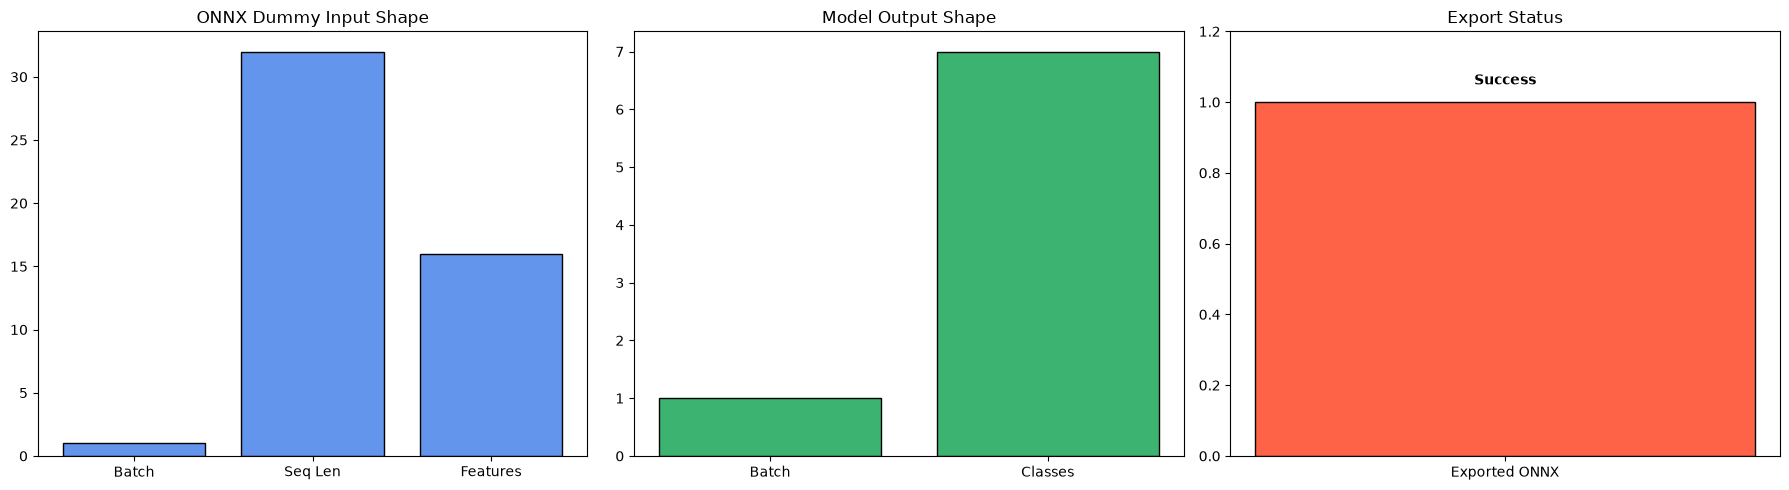

In [40]:
# Cell 10.1 — ONNX Export Sanity Visualization (Matplotlib)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Input shape visualization
input_shape = dummy_input.shape
axes[0].bar(
    ["Batch", "Seq Len", "Features"],
    [input_shape[0], input_shape[1], input_shape[2]],
    color="cornflowerblue",
    edgecolor="black"
)
axes[0].set_title("ONNX Dummy Input Shape")

# Model output shape (inference check)
with torch.no_grad():
    out = model(dummy_input)
out_shape = out.shape

axes[1].bar(
    ["Batch", "Classes"],
    [out_shape[0], out_shape[1]],
    color="mediumseagreen",
    edgecolor="black"
)
axes[1].set_title("Model Output Shape")

# Export status visualization
axes[2].bar(
    ["Exported ONNX"],
    [1],
    color="tomato",
    edgecolor="black"
)
axes[2].set_ylim(0, 1.2)
axes[2].set_title("Export Status")
axes[2].text(0, 1.05, "Success", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()